In [1]:
%reload_ext autoreload
%autoreload 2
import sys, os
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import optax
from tqdm.notebook import tqdm

# Add project root to path
project_root = '/sdf/group/neutrino/pgranger/larnd-sim-jax/src'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

%cd /sdf/group/neutrino/pgranger/larnd-sim-jax

from larndsim.consts_jax import build_params_class, load_detector_properties, load_lut
from larndsim.losses_jax import adc2charge
from optimize.strategies import LUTSimulation, LUTProbabilisticSimulation, ProbabilisticLossStrategy, compute_occurrence_indices
from optimize.dataio import TracksDataset, DataLoader
from optimize.ranges import ranges
from optimize.dedx_utils import student_t_nll, DEDX_STUDENT_NU, DEDX_STUDENT_LOC, DEDX_STUDENT_SCALE

def map_norm_to_phys(val, key, scheme="sigmoid", scale=1.0):
    if scheme == "sigmoid":
        low, high = ranges[key]['min'], ranges[key]['max']
        return low + (high - low) * jax.nn.sigmoid(scale * val)
    return val

def map_phys_to_norm(val, key, scheme="sigmoid", scale=1.0):
    if scheme == "sigmoid":
        low, high = ranges[key]['min'], ranges[key]['max']
        eps = jnp.finfo(jnp.float32).eps
        frac = jnp.clip((val - low) / (high - low), eps, 1.0 - eps)
        return jnp.log(frac / (1.0 - frac)) / scale
    return val

print("Setup complete with parameter mapping logic.")

/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/sdf/group/neutrino/pgranger/larnd-sim-jax
Setup complete with parameter mapping logic.


In [2]:
# --- Configuration ---
INPUT_FILE = '/sdf/data/neutrino/cyifan/diffsim_input/true_through_muon_edep_10cm_vol1cm.h5'
LUT_FILE = 'src/larndsim/detector_properties/response_44_v2a_full_tick.npz'
DET_PROPS = 'src/larndsim/detector_properties/module0.yaml'
PIXEL_LAYOUTS = 'src/larndsim/pixel_layouts/multi_tile_layout-2.4.16_v4.yaml'

RELEVANT_PARAMS = ['Ab', 'kb', 'lifetime', 'tran_diff', 'long_diff', 'eField', 'shift_x', 'shift_y', 'shift_z']

ELECTRON_SAMPLING_RESOLUTION = 0.1
NUMBER_PIX_NEIGHBORS = 4
SIGNAL_LENGTH = 150

# --- Setup Simulation Objects ---
ParamsClass = build_params_class(RELEVANT_PARAMS)
ref_params = load_detector_properties(ParamsClass, DET_PROPS, PIXEL_LAYOUTS)
ref_params = ref_params.replace(
    electron_sampling_resolution=ELECTRON_SAMPLING_RESOLUTION,
    number_pix_neighbors=NUMBER_PIX_NEIGHBORS,
    signal_length=SIGNAL_LENGTH,
    time_window=SIGNAL_LENGTH
)

response, ref_params = load_lut(LUT_FILE, ref_params)
sim_stochastic = LUTSimulation(response)
sim_probabilistic = LUTProbabilisticSimulation(response)
loss_strategy = ProbabilisticLossStrategy(sigma_charge=500.0, eps=1e-8)

print("Configuration complete.")

INFO:larndsim.consts_jax:Loading response from npz file
Could not load symbol cuFuncGetName. Error: /.singularity.d/libs/libcuda.so.1: undefined symbol: cuFuncGetName


Configuration complete.


In [8]:
# --- Target Generation ---
dataset = TracksDataset(filename=INPUT_FILE, nevents=-1, max_nbatch=1, max_batch_len=1000,
                        electron_sampling_resolution=ELECTRON_SAMPLING_RESOLUTION)
dataloader = DataLoader(dataset, batch_size=1)

track_fields = dataset.get_track_fields()
tracks_raw = jnp.array(dataloader[0].reshape(-1, len(track_fields)))
print(f"Loaded {tracks_raw.shape[0]} segments.")

# True parameters for generation
TRUE_KB = 0.0486
TRUE_AB = 0.81
true_dedx = tracks_raw[:, track_fields.index('dEdx')]
base_params = ref_params.replace(kb=TRUE_KB, Ab=TRUE_AB)

def gen_target(efield, label):
    p = base_params.replace(eField=efield)
    out = sim_stochastic.predict(p, tracks_raw, track_fields, rngkey=42)
    print(f"Generated Target {label} at {efield} kV/cm: {len(out['adcs'])} hits.")
    return {
        'pixel_id': out['hit_pixels'],
        'ticks': out['ticks'],
        'adcs': out['adcs'],
        'hit_prob': out['hit_prob']
    }

E_A, E_B = 0.50, 0.40
target_A = gen_target(E_A, "A")
target_B = gen_target(E_B, "B")

INFO:optimize.dataio:-- The used simulation data includes a total track length of 957.2027721405029 cm.
INFO:optimize.dataio:-- The number of simulation batches is 1.


Loaded 9722 segments.
Generated Target A at 0.5 kV/cm: 3921 hits.
Generated Target B at 0.4 kV/cm: 3040 hits.


In [9]:
# --- Optimization Setup ---

# Each sample has its own independent dEdx (as in real data, where you cannot
# share dEdx between two independent measurements).
# The dEdx prior (Student-t) anchors both dEdx arrays to the physical scale,
# preventing the optimizer from compensating Ab/kb shifts by sliding dEdx.
#
# With two fields and dEdx independently constrained by the prior:
#   R = Ab / (1 + kb * dEdx / E)
# The field contrast between E_A and E_B changes the relative recombination
# in a way that depends on kb but not on dEdx alone, breaking the degeneracy.

SHARED_PARAMS = ['kb', 'Ab']
INIT_PHYS = {
    'kb': 0.040,  # Truth: 0.0486
    'Ab': 0.82,   # Truth: 0.81
}

# Convert to normalized space for optimization
init_shared_norm = {k: float(map_phys_to_norm(v, k)) for k, v in INIT_PHYS.items()}
print("Initial normalized values:", {k: f"{v:.4f}" for k, v in init_shared_norm.items()})
print("Round-trip check (should match INIT_PHYS):",
      {k: float(map_norm_to_phys(v, k)) for k, v in init_shared_norm.items()})

# Independent dEdx per sample — initialized to 2.0 MeV/cm
init_log_dedx_A = jnp.full((tracks_raw.shape[0],), jnp.log(2.0))
init_log_dedx_B = jnp.full((tracks_raw.shape[0],), jnp.log(2.0))

trainable_state = {
    'shared':      init_shared_norm,  # normalized (unconstrained) floats
    'log_dedx_A':  init_log_dedx_A,
    'log_dedx_B':  init_log_dedx_B,
}

# Optimizer
optimizer = optax.multi_transform(
    {
        'calib': optax.adam(learning_rate=5e-2),
        'dedx':  optax.adam(learning_rate=1e-2)
    },
    {
        'shared':      'calib',
        'log_dedx_A':  'dedx',
        'log_dedx_B':  'dedx',
    }
)

opt_state = optimizer.init(trainable_state)

print("Optimization state initialized.")


Initial normalized values: {'kb': '-1.3863', 'Ab': '-0.1335'}
Round-trip check (should match INIT_PHYS): {'kb': 0.03999999910593033, 'Ab': 0.8199999928474426}
Optimization state initialized.


In [13]:
# --- Joint Loss Logic ---

def joint_loss_fn(state):
    # Map normalized → physical for all shared calibration params
    phys_shared = {k: map_norm_to_phys(v, k) for k, v in state['shared'].items()}

    dedx_idx = track_fields.index('dEdx')
    dx_idx   = track_fields.index('dx')
    dE_idx   = track_fields.index('dE')
    dx       = tracks_raw[:, dx_idx]

    def compute_sample_loss(log_dedx, efield, target):
        dedx_fitted = jnp.exp(log_dedx)
        tracks_fit  = tracks_raw.at[:, dedx_idx].set(dedx_fitted)
        tracks_fit  = tracks_fit.at[:, dE_idx].set(dedx_fitted * dx)

        p = ref_params.replace(**phys_shared, eField=efield)
        pred = sim_probabilistic.predict(p, tracks_fit, track_fields, 42)
        hit_loss, _ = loss_strategy.compute(p, pred, target)

        # dEdx prior — anchors the dEdx scale so Ab/kb can't be compensated
        # by freely sliding dedx. Weight is relative to hit_loss magnitude.
        prior = student_t_nll(dedx_fitted, DEDX_STUDENT_NU, DEDX_STUDENT_LOC,
                              DEDX_STUDENT_SCALE, weights=dx) * PRIOR_WEIGHT
        return hit_loss + prior

    loss_A = compute_sample_loss(state['log_dedx_A'], E_A, target_A)
    loss_B = compute_sample_loss(state['log_dedx_B'], E_B, target_B)

    return loss_A + loss_B

# Prior weight: needs to be large enough that the prior dominates over
# the hit-loss gradient when dedx drifts away from the physical distribution.
# Increase if Ab/kb still don't converge; the loss will diagnose this.
PRIOR_WEIGHT = 10000.0

print(f"Joint loss function defined.  PRIOR_WEIGHT={PRIOR_WEIGHT}")


Joint loss function defined.  PRIOR_WEIGHT=10000.0


In [14]:
# --- Training Loop ---

def train_step(state, opt_state):
    loss, grads = jax.value_and_grad(joint_loss_fn)(state)
    updates, next_opt_state = optimizer.update(grads, opt_state, state)
    next_state = optax.apply_updates(state, updates)
    return next_state, next_opt_state, loss

history = {'loss': [], 'kb': [], 'Ab': [], 'mae_A': [], 'mae_B': []}

N_ITER = 300
curr_state = trainable_state
curr_opt_state = opt_state

print("Starting fit...")
for i in tqdm(range(N_ITER)):
    curr_state, curr_opt_state, loss_val = train_step(curr_state, curr_opt_state)

    phys = {k: float(map_norm_to_phys(v, k)) for k, v in curr_state['shared'].items()}
    history['loss'].append(float(loss_val))
    history['kb'].append(phys['kb'])
    history['Ab'].append(phys['Ab'])

    mae_A = jnp.mean(jnp.abs(jnp.exp(curr_state['log_dedx_A']) - true_dedx))
    mae_B = jnp.mean(jnp.abs(jnp.exp(curr_state['log_dedx_B']) - true_dedx))
    history['mae_A'].append(float(mae_A))
    history['mae_B'].append(float(mae_B))

print("Fit complete.")
print(f"Final kb={history['kb'][-1]:.5f}  (truth {TRUE_KB}),  "
      f"Ab={history['Ab'][-1]:.4f}  (truth {TRUE_AB})")


Starting fit...


  0%|          | 0/300 [00:00<?, ?it/s]

Fit complete.
Final kb=0.04330  (truth 0.0486),  Ab=0.8077  (truth 0.81)


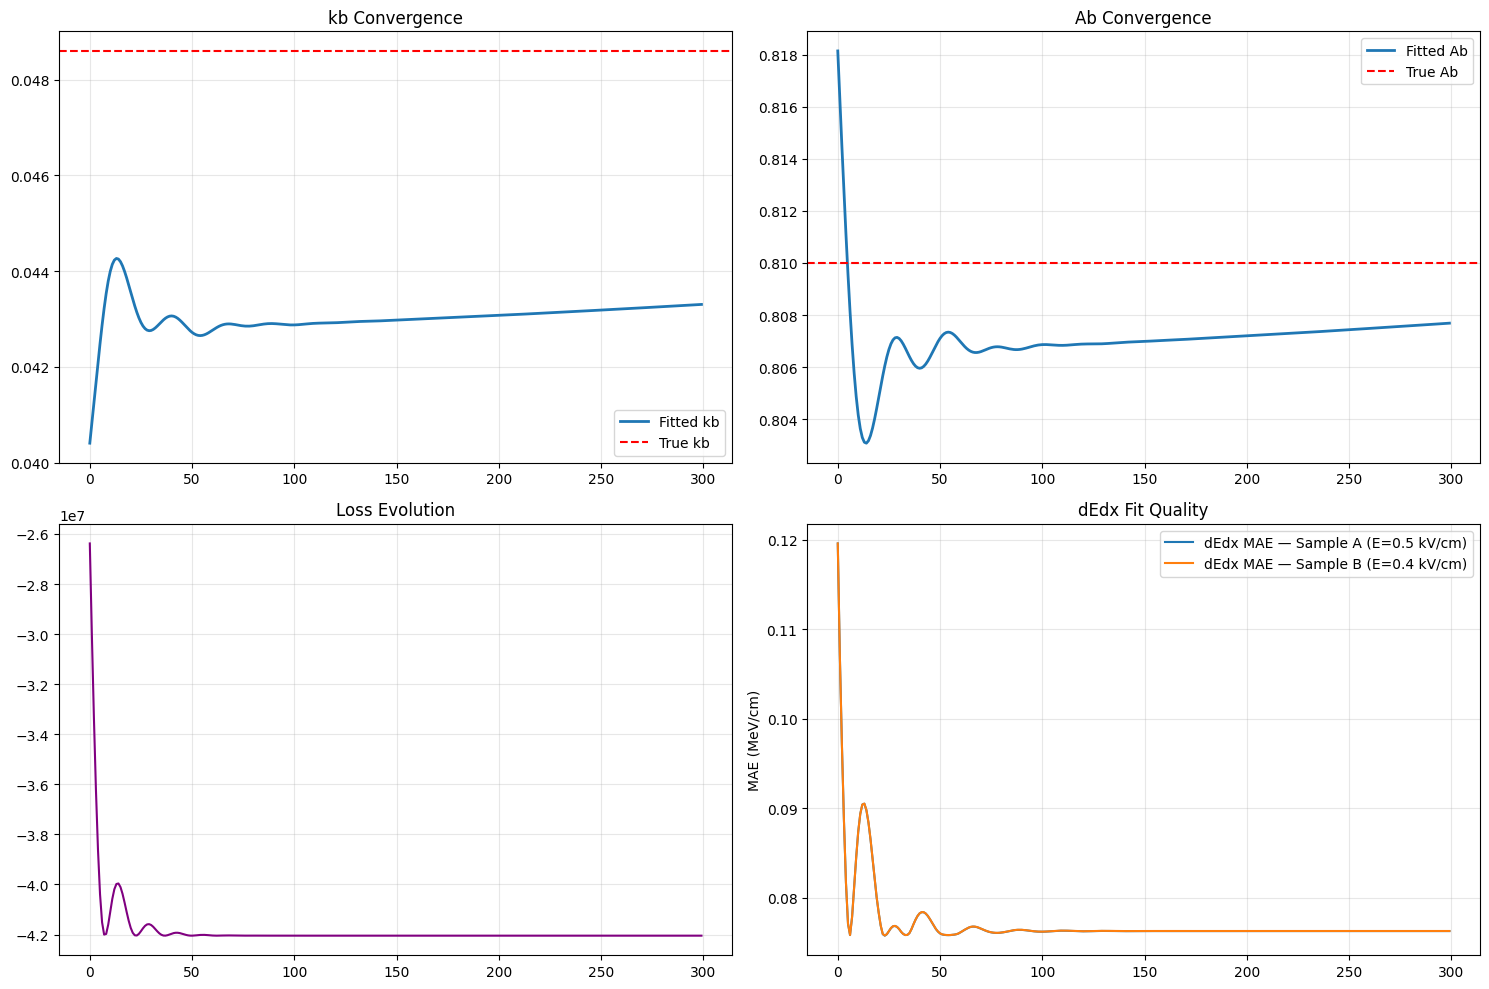

In [15]:
# --- Visualization ---
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(history['kb'], label='Fitted kb', lw=2)
plt.axhline(TRUE_KB, color='r', ls='--', label='True kb')
plt.title("kb Convergence")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(history['Ab'], label='Fitted Ab', lw=2)
plt.axhline(TRUE_AB, color='r', ls='--', label='True Ab')
plt.title("Ab Convergence")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(history['loss'], label='Total Loss', color='purple')
plt.title("Loss Evolution")
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(history['mae_A'], label=f'dEdx MAE — Sample A (E={E_A} kV/cm)')
plt.plot(history['mae_B'], label=f'dEdx MAE — Sample B (E={E_B} kV/cm)')
plt.title("dEdx Fit Quality")
plt.ylabel("MAE (MeV/cm)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [56]:

# --- Prior-weight diagnostic ---
# If Ab/kb still don't converge, the prior is too weak relative to the hit loss
# and dEdx is absorbing the (Ab, kb) error.  This cell measures the gradient
# magnitudes at the initial state so you can tune PRIOR_WEIGHT accordingly.
#
# Rule of thumb: |grad_prior / grad_hit_loss| on log_dedx should be >> 1
# so the prior dominates and dedx is pinned near its true distribution.

def _split_loss(state):
    phys_shared = {k: map_norm_to_phys(v, k) for k, v in state['shared'].items()}
    dedx_idx = track_fields.index('dEdx')
    dx_idx   = track_fields.index('dx')
    dE_idx   = track_fields.index('dE')
    dx       = tracks_raw[:, dx_idx]

    def _hit_loss_only(log_dedx, efield, target):
        dedx_f = jnp.exp(log_dedx)
        tf = tracks_raw.at[:, dedx_idx].set(dedx_f).at[:, dE_idx].set(dedx_f * dx)
        p = ref_params.replace(**phys_shared, eField=efield)
        hl, _ = loss_strategy.compute(p, sim_probabilistic.predict(p, tf, track_fields, 42), target)
        return hl

    def _prior_only(log_dedx):
        dedx_f = jnp.exp(log_dedx)
        return student_t_nll(dedx_f, DEDX_STUDENT_NU, DEDX_STUDENT_LOC,
                             DEDX_STUDENT_SCALE, weights=dx) * PRIOR_WEIGHT

    grad_hit_A  = jax.grad(_hit_loss_only)(state['log_dedx_A'], E_A, target_A)
    grad_hit_B  = jax.grad(_hit_loss_only)(state['log_dedx_B'], E_B, target_B)
    grad_prior_A = jax.grad(_prior_only)(state['log_dedx_A'])
    grad_prior_B = jax.grad(_prior_only)(state['log_dedx_B'])

    return grad_hit_A, grad_hit_B, grad_prior_A, grad_prior_B

gha, ghb, gpa, gpb = _split_loss(trainable_state)

def _rms(g): return float(jnp.sqrt(jnp.mean(g**2)))

print(f"Gradient RMS on log_dedx at initialisation  (PRIOR_WEIGHT={PRIOR_WEIGHT})")
print(f"  Sample A — hit loss: {_rms(gha):.4f}   prior: {_rms(gpa):.4f}"
      f"   ratio prior/hit = {_rms(gpa)/(_rms(gha)+1e-12):.2f}")
print(f"  Sample B — hit loss: {_rms(ghb):.4f}   prior: {_rms(gpb):.4f}"
      f"   ratio prior/hit = {_rms(gpb)/(_rms(ghb)+1e-12):.2f}")
print()
print("If ratio < 1 the prior is too weak — increase PRIOR_WEIGHT in cell 5 and rerun.")
print("If ratio >> 10 the prior dominates and dedx is well-anchored.")


Gradient RMS on log_dedx at initialisation  (PRIOR_WEIGHT=100.0)
  Sample A — hit loss: 26.7246   prior: 193.2071   ratio prior/hit = 7.23
  Sample B — hit loss: 19.6907   prior: 193.2071   ratio prior/hit = 9.81

If ratio < 1 the prior is too weak — increase PRIOR_WEIGHT in cell 5 and rerun.
If ratio >> 10 the prior dominates and dedx is well-anchored.
